# Experiment Claims

**Source files:** `markov_*.pkl`, `fsm_*.pkl`, `iid_model_fsm_alpha_sweep.pkl`

---

## Claim 6 (Markov): Specialized Markov transformers dominate at high autocorrelation.

A separate transformer is trained per p_stay value. The most extreme case is p_stay=0.99: the transformer holds at ~0.09 BPS across all l while Laplace grows from 0.41 at l=10 to 0.87 at l=499. Laplace estimates the marginal from running counts, but the marginal of a slow-mixing chain drifts depending on initial state: it converges to the wrong thing over a finite window.

At p_stay=0.0 (perfectly alternating) the transformer collapses toward zero BPS. Laplace stays near 1.0 because the marginal of an alternating chain is exactly p=0.5. Counting gets Laplace nowhere on a structure that is fully expressed in transitions.

*Key numbers:* p_stay=0.99, l=499: transformer 0.0845, Laplace 0.8727. p_stay=0.0, l=499: transformer 0.0071, Laplace 1.0083.

---

## Claim 7 (FSM Dirichlet): The specialized transformer beats Laplace and CTW. The IID transformer does not.

Two experiments were run. First: a separate transformer trained per alpha value (specialized). Second: the single IID transformer applied across all alpha values (general). The specialized model wins at alpha ≥ 0.5. The IID transformer does not beat Laplace or CTW: unlike the Markov OOD case, active learning alone is not enough for the FSM source class.

CTW performs poorly at short l (l ≤ 50) because it needs at least depth=8 symbols to build a full context window, so the first depth+1 predictions are flat 0.5 priors. At larger l it closes in on Laplace.

*Note: key numbers will be updated after re-running experiments with the corrected ctw_p_array (causal alignment fix applied 2026-05-14).*


In [164]:
import sys
sys.path.append('../../')
from ctw.ctw import CTW

from mingpt.model import GPT
from mingpt.trainer import Trainer
import torch
from torch.utils.data import Dataset
import numpy as np
import torch
import torch.nn.functional as F
from mingpt.model import GPT
import pickle
import matplotlib.pyplot as plt

In [165]:
def markov_generate(p_stay, N):
    state = np.random.choice([0, 1])  # stationary is uniform for symmetric chain
    seq = [state]
    for _ in range(N - 1):
        if np.random.rand() < p_stay:
            seq.append(state)  # stay
        else:
            state = 1 - state  # switch
            seq.append(state)
    return np.array(seq)


# Dirichlet array generation

In [166]:
import numpy as np

def random_transition_matrix(n_states, concentration):
    alpha = np.ones(n_states) * concentration
    return np.random.dirichlet(alpha, size=n_states)  # shape (n_states, n_states)

def finite_state_generate(transition_matrix, emission_probs, N):
    n_states = len(emission_probs)
    state = np.random.choice(n_states)
    seq = []
    for _ in range(N):
        bit = 1 if np.random.rand() < emission_probs[state] else 0
        seq.append(bit)
        state = np.random.choice(n_states, p=transition_matrix[state])
    return np.array(seq)



In [167]:
class FixedFSMDataset(Dataset):
    def __init__(self, emission_probs, n=500, num_samples=10000, n_states=4, concentration=0.1):
        self.block_size = n - 1
        self.data = []
        for _ in range(num_samples):
            T = random_transition_matrix(n_states, concentration)
            seq = torch.tensor(finite_state_generate(T, emission_probs, n), dtype=torch.long)
            x = seq[:-1].clone()
            y = seq[1:].clone()
            self.data.append((x, y))

    def get_block_size(self):
        return self.block_size

    def __getitem__(self, idx):
        return self.data[idx]

    def __len__(self):
        return len(self.data)

In [168]:
# Model configure

model_save_folder = './models/'

def model_configure(dataset, iters=1000, learn_rate=1e-4):
    model_config = GPT.get_default_config()
    model_config.model_type = 'gpt-nano'
    model_config.vocab_size = 2
    model_config.block_size = dataset.get_block_size()
    model = GPT(model_config)

    device = 'mps'
    model = model.to(device)

    train_config = Trainer.get_default_config()
    train_config.learning_rate = learn_rate
    train_config.max_iters = iters
    train_config.num_workers = 0
    train_config.device = 'mps'
    trainer = Trainer(train_config, model, dataset)
    return model, trainer

def batch_end_callback(trainer):
    if trainer.iter_num % 100 == 0:
        print(f"iter_dt {trainer.iter_num}; iter {trainer.iter_num}: train loss {trainer.loss.item():.5f}")

def train_run(model, trainer, output_name):
    save_dir = model_save_folder + output_name
    print(f'Saving to {save_dir}')
    trainer.set_callback('on_batch_end', batch_end_callback)
    trainer.run()
    torch.save({
        'state_dict': model.state_dict(),
        'block_size': model.block_size
    }, save_dir)
    print(f'Saved to {save_dir}')

# Experiment infrastructure

In [169]:
experiment_save_folder = './experiments/'
N_values = [10, 25, 50, 100, 200, 499]

In [170]:

def iid_generate(p_dict, N):
    p0 = p_dict[0]
    p1 = p_dict[1]
    return np.random.choice([0,1], size=N, p=[p0, p1])

def generate_bin_pmf():
    p = np.random.rand()
    dict_out = {
        0: p,
        1: 1-p
    }
    return dict_out

def convert_sample_to_pmf(sample):
    values, counts = np.unique(sample, return_counts=True)
    probs = counts/counts.sum()
    return dict(zip(values, probs))

def entropy_calc(pmf):
    pmf = clean_pmf(pmf)
    pmf_array = np.asarray(list(pmf.values()))
    return -np.sum(pmf_array * np.log2(pmf_array))

def clean_pmf(pmf):
    return {k: v for k, v in pmf.items() if v > 0.0}

# CTW prediction machine

In [171]:

def ctw_p_array(sequence, depth=8):
    sequence = [int(x) for x in sequence]
    ctw = CTW(depth=depth, symbols=2)
    distributions = ctw.predict_sequence(sequence)
    # predict_sequence returns distributions[:,n] AFTER updating on seq[depth+n].
    # So distributions[1, n] predicts seq[depth+n+1], not seq[depth+n].
    # Correct causal alignment: pad depth+1 flat priors, then use p_ones[:-1].
    p_ones = distributions[1, :].tolist()
    p_array = [0.5] * (depth + 1) + p_ones[:-1]
    return p_array

p = generate_bin_pmf()
seq = iid_generate(p, 20)
print(ctw_p_array(seq))


[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.6875, 0.7954545454545455, 0.8571428571428571, 0.8916666666666667, 0.9123831775700935, 0.9260563380281691, 0.6785714285714285, 0.8197642543859649, 0.8391193324314876, 0.8543530879515999]


In [172]:
def sequential_universal_source_coding(seq, p_array = None):
    total_bits = 0
    k = 0
    i = 0

    for bit in seq:
        if p_array is not None:
            p1 = p_array[i]
        else:
            p1 = (k+1) / (i+2)
        p0 = 1-p1

        if bit == 1:
            total_bits += -np.log2(p1)
        else:
            total_bits += -np.log2(p0)
        k += bit
        i += 1

    bits_per_symbol = total_bits / len(seq)
    return bits_per_symbol

In [173]:

# generate an array of probabilities given a bit sequence

def transformer_p_array(sequence, model, device='mps'):
    model.eval()
    sequence=torch.tensor(sequence, dtype=torch.long, device=device).unsqueeze(0)

    with torch.no_grad():
        logits, _ = model(sequence)  # [1, T, vocab_size]
        # convert to probabilities
        probs = F.softmax(logits, dim=-1)  # [1, T, vocab_size]
        # extract probability of token=1 at each timestep
        p_array = [0.5] + probs[0, :-1, 1].tolist()
    
    return p_array

In [174]:
def load_model(model_dir):
    checkpoint = torch.load(model_dir, map_location='cpu')
    block_size = checkpoint['block_size']
    
    model_config = GPT.get_default_config()
    model_config.model_type = 'gpt-nano'
    model_config.vocab_size = 2
    model_config.block_size = block_size
    
    model = GPT(model_config)
    model.load_state_dict(checkpoint['state_dict'])
    model = model.to('mps')
    model.eval()
    return model

In [175]:
def run_fsm_experiment(model, alpha, n_states, emission_probs, N_values, output_file, n_trials=100, device='mps', ctw_depth=8):
    all_results = {alpha: {}}
    save_dir = experiment_save_folder + output_file
    T = random_transition_matrix(n_states, alpha)
    
    for N in N_values:
        laplace_bps_trials = []
        transformer_bps_trials = []
        ctw_bps_trials = []
        
        for trial in range(n_trials):
            seq = finite_state_generate(T, emission_probs, N)
            
            laplace_bps_trials.append(sequential_universal_source_coding(seq))
            
            p_array = transformer_p_array(seq, model, device=device)
            transformer_bps_trials.append(sequential_universal_source_coding(seq, p_array=p_array))
            
            p_array_ctw = ctw_p_array(seq, depth=ctw_depth)
            ctw_bps_trials.append(sequential_universal_source_coding(seq, p_array=p_array_ctw))
        
        all_results[alpha][N] = {
            'laplace': (np.mean(laplace_bps_trials), np.std(laplace_bps_trials)),
            'transformer': (np.mean(transformer_bps_trials), np.std(transformer_bps_trials)),
            'ctw': (np.mean(ctw_bps_trials), np.std(ctw_bps_trials)),
        }
        print(f"  N={N}: laplace={np.mean(laplace_bps_trials):.4f}, transformer={np.mean(transformer_bps_trials):.4f}, ctw={np.mean(ctw_bps_trials):.4f}")
    
    with open(save_dir, 'wb') as f:
        pickle.dump(all_results, f)
    print(f'Saved to {save_dir}')

In [176]:
import os

N_values      = [10, 25, 50, 100, 200, 300, 499]
n_trials      = 100
seq_samples   = 500
num_samples   = 10000
iters         = 500
emission_probs = [0.1, 0.35, 0.65, 0.9]
alpha_sweep   = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
n_states      = 4

for alpha in alpha_sweep:
    model_path = model_save_folder + f'fsm_{alpha}_model.pt'
    exp_path   = experiment_save_folder + f'fsm_{alpha}_experiment.pkl'

    if os.path.exists(model_path):
        print(f'Checkpoint found, loading fsm_{alpha}_model.pt')
        model = load_model(model_path)
    else:
        dataset = FixedFSMDataset(emission_probs=emission_probs, n=seq_samples,
                                   num_samples=num_samples, n_states=n_states,
                                   concentration=alpha)
        model, trainer = model_configure(dataset, iters=iters)
        train_run(model, trainer, f'fsm_{alpha}_model.pt')

    if os.path.exists(exp_path):
        print(f'Experiment found, skipping fsm_{alpha}_experiment.pkl')
    else:
        run_fsm_experiment(model, alpha, n_states, emission_probs, N_values,
                           output_file=f'fsm_{alpha}_experiment.pkl',
                           n_trials=n_trials, device='mps')


Checkpoint found, loading fsm_0.1_model.pt
number of parameters: 0.11M
  N=10: laplace=0.9641, transformer=0.9561, ctw=1.0000
  N=25: laplace=0.8792, transformer=0.8941, ctw=0.9495
  N=50: laplace=0.8587, transformer=0.8721, ctw=0.8930
  N=100: laplace=0.8408, transformer=0.8544, ctw=0.8677
  N=200: laplace=0.8221, transformer=0.8323, ctw=0.8330
  N=300: laplace=0.8200, transformer=0.8276, ctw=0.8303
  N=499: laplace=0.8099, transformer=0.8159, ctw=0.8164
Saved to ./experiments/fsm_0.1_experiment.pkl
Checkpoint found, loading fsm_0.5_model.pt
number of parameters: 0.11M
  N=10: laplace=1.0274, transformer=0.9855, ctw=1.0000
  N=25: laplace=1.0394, transformer=0.9978, ctw=1.0611
  N=50: laplace=1.0165, transformer=0.9938, ctw=1.0353
  N=100: laplace=1.0028, transformer=0.9918, ctw=1.0193
  N=200: laplace=0.9982, transformer=0.9929, ctw=1.0069
  N=300: laplace=0.9936, transformer=0.9907, ctw=0.9999
  N=499: laplace=0.9907, transformer=0.9891, ctw=0.9963
Saved to ./experiments/fsm_0.5_exp

In [177]:
import os, pickle

SAVE_PATH = experiment_save_folder + 'iid_model_fsm_alpha_sweep.pkl'

if os.path.exists(SAVE_PATH):
    print(f'Checkpoint found, loading iid_model_fsm_alpha_sweep.pkl')
    with open(SAVE_PATH, 'rb') as f:
        iid_alpha_results = pickle.load(f)
else:
    model_iid = load_model('../IID/models/iid_model.pt')

    N_values = [10, 25, 50, 100, 200, 300, 499]
    n_trials = 100
    seq_samples = 500
    num_samples = 10000
    iters = 500
    emission_probs = [0.1, 0.35, 0.65, 0.9]
    alpha_sweep = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
    n_states = 4

    iid_alpha_results = {}
    for alpha in alpha_sweep:
        print(f'Running alpha={alpha} with iid model')
        iid_alpha_results[alpha] = {}
        for N in N_values:
            laplace_bps_trials = []
            transformer_bps_trials = []
            ctw_bps_trials = []
            for _ in range(n_trials):
                T = random_transition_matrix(n_states, alpha)
                seq = finite_state_generate(T, emission_probs, N)
                laplace_bps_trials.append(sequential_universal_source_coding(seq))
                p_array = transformer_p_array(seq, model_iid, device='mps')
                transformer_bps_trials.append(sequential_universal_source_coding(seq, p_array=p_array))
                p_array_ctw = ctw_p_array(seq)
                ctw_bps_trials.append(sequential_universal_source_coding(seq, p_array=p_array_ctw))
            iid_alpha_results[alpha][N] = {
                'laplace':     (np.mean(laplace_bps_trials), np.std(laplace_bps_trials)),
                'transformer': (np.mean(transformer_bps_trials), np.std(transformer_bps_trials)),
                'ctw':         (np.mean(ctw_bps_trials), np.std(ctw_bps_trials)),
            }
            print(f'  N={N}: laplace={np.mean(laplace_bps_trials):.4f}, transformer={np.mean(transformer_bps_trials):.4f}, ctw={np.mean(ctw_bps_trials):.4f}')

    with open(SAVE_PATH, 'wb') as f:
        pickle.dump(iid_alpha_results, f)
    print('Saved to', SAVE_PATH)


number of parameters: 0.11M
Running alpha=0.1 with iid model
  N=10: laplace=0.9669, transformer=0.9654, ctw=1.0000
  N=25: laplace=0.9682, transformer=0.9707, ctw=1.0112
  N=50: laplace=0.9138, transformer=0.9139, ctw=0.9555
  N=100: laplace=0.9217, transformer=0.9226, ctw=0.9649
  N=200: laplace=0.8628, transformer=0.8630, ctw=0.9098
  N=300: laplace=0.8900, transformer=0.8910, ctw=0.9190
  N=499: laplace=0.8830, transformer=0.8855, ctw=0.9571
Running alpha=0.5 with iid model
  N=10: laplace=1.0563, transformer=1.0610, ctw=1.0000
  N=25: laplace=1.0185, transformer=1.0220, ctw=1.0351
  N=50: laplace=1.0095, transformer=1.0112, ctw=1.0330
  N=100: laplace=0.9954, transformer=0.9959, ctw=1.0148
  N=200: laplace=0.9672, transformer=0.9683, ctw=0.9820
  N=300: laplace=0.9726, transformer=0.9735, ctw=0.9827
  N=499: laplace=0.9637, transformer=0.9646, ctw=0.9800
Running alpha=1.0 with iid model
  N=10: laplace=1.0757, transformer=1.0799, ctw=1.0000
  N=25: laplace=1.0387, transformer=1.04

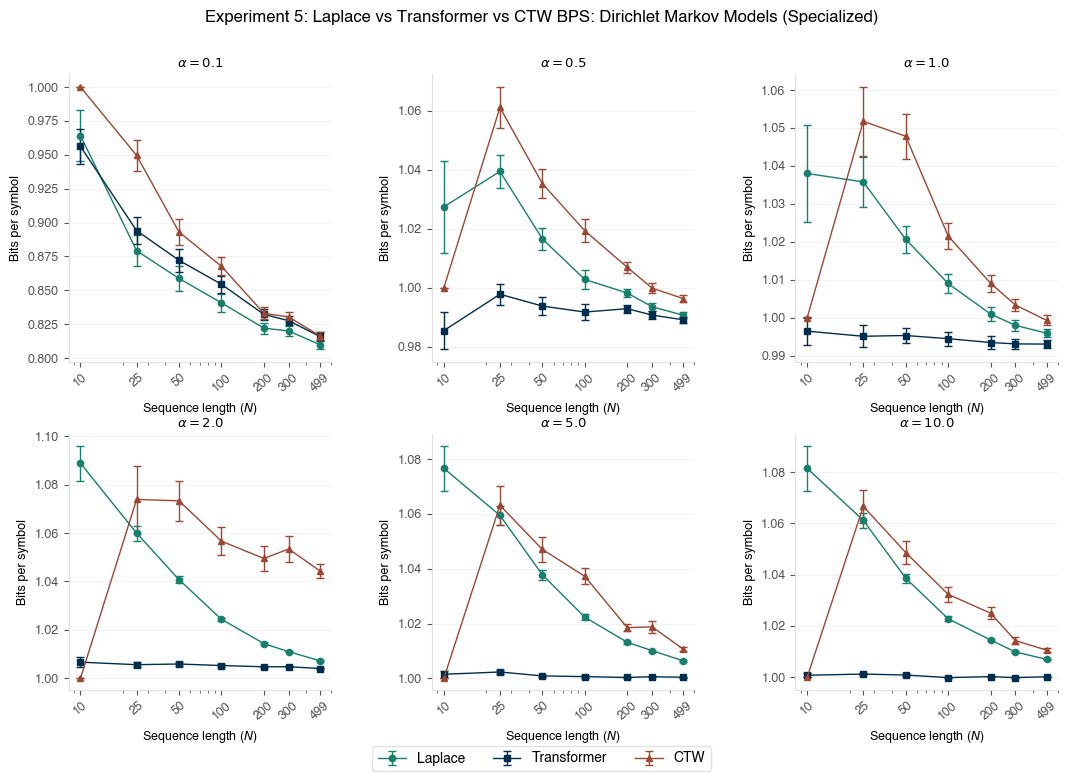

Saved figures/fsm_bps_grid_specialized


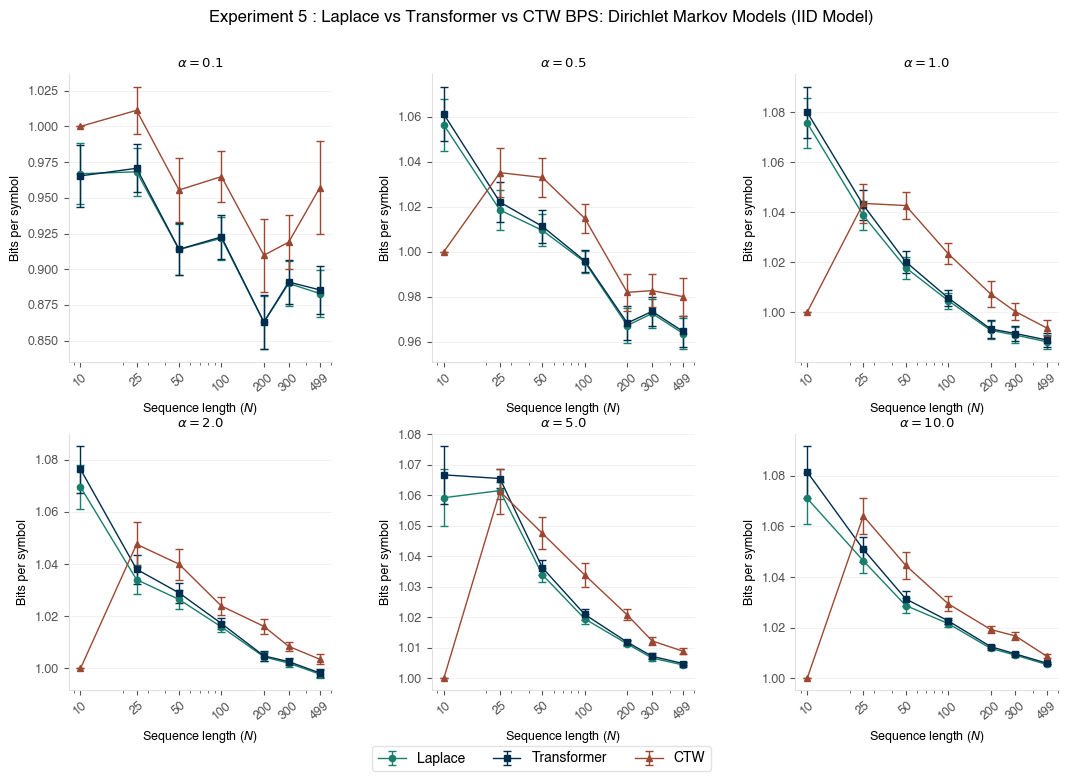

Saved figures/fsm_bps_grid_iid


In [178]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import pickle
import os
os.makedirs('figures', exist_ok=True)

# -- Style ------------------------------------------------------------------
C_TRANSFORMER = '#002d4d'
C_LAPLACE     = '#177F6B'
C_CTW         = '#9C4732'
BG            = '#FFFFFF'
GRID          = '#E0E0E0'

matplotlib.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'Arial', 'DejaVu Sans'],
    'axes.facecolor':    BG,
    'figure.facecolor':  BG,
    'axes.edgecolor':    GRID,
    'axes.linewidth':    0.8,
    'grid.color':        GRID,
    'grid.linewidth':    0.6,
    'xtick.color':       '#555555',
    'ytick.color':       '#555555',
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'axes.labelsize':    10,
    'axes.titlesize':    10,
    'axes.titleweight':  'bold',
    'legend.fontsize':   9,
    'legend.framealpha': 0.92,
    'legend.edgecolor':  GRID,
    'lines.linewidth':   1.0,
    'lines.markersize':  4.5,
})

def style_ax(ax):
    ax.grid(True, axis='y', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def set_log_xticks(ax, vals):
    ax.set_xscale('log')
    ax.set_xticks(vals)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis='x', rotation=40)


def plot_fsm_sweep(all_data, alpha_sweep, N_values, title, save_stem, n_trials=100):
    fig = plt.figure(figsize=(11, 8))
    fig.patch.set_facecolor(BG)

    gs_top = gridspec.GridSpec(1, 3, top=0.89, bottom=0.53, left=0.07, right=0.97, wspace=0.38)
    gs_bot = gridspec.GridSpec(1, 3, top=0.44, bottom=0.12, left=0.07, right=0.97, wspace=0.38)
    axes_top = [fig.add_subplot(gs_top[0, i]) for i in range(3)]
    axes_bot = [fig.add_subplot(gs_bot[0, i]) for i in range(3)]
    all_axes = axes_top + axes_bot

    for ax, alpha in zip(all_axes, alpha_sweep):
        data   = all_data[alpha]
        lap_m  = [data[N]['laplace'][0]     for N in N_values]
        tr_m   = [data[N]['transformer'][0] for N in N_values]
        ctw_m  = [data[N]['ctw'][0]         for N in N_values]
        lap_se = [data[N]['laplace'][1]     / n_trials**0.5 for N in N_values]
        tr_se  = [data[N]['transformer'][1] / n_trials**0.5 for N in N_values]
        ctw_se = [data[N]['ctw'][1]         / n_trials**0.5 for N in N_values]

        ax.errorbar(N_values, lap_m, yerr=lap_se, fmt='o-', capsize=3,
                    color=C_LAPLACE, lw=1.0, ms=4.5, label='Laplace')
        ax.errorbar(N_values, tr_m,  yerr=tr_se,  fmt='s-', capsize=3,
                    color=C_TRANSFORMER, lw=1.0, ms=4.5, label='Transformer')
        ax.errorbar(N_values, ctw_m, yerr=ctw_se, fmt='^-', capsize=3,
                    color=C_CTW, lw=1.0, ms=4.5, label='CTW')

        set_log_xticks(ax, N_values)
        ax.set_title(f'$\\alpha={alpha}$', fontsize=9.5, pad=5)
        ax.set_xlabel('Sequence length ($N$)', fontsize=9)
        ax.set_ylabel('Bits per symbol', fontsize=9)
        style_ax(ax)

    handles, labels = all_axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, 0.01), frameon=True, fontsize=10)
    fig.suptitle(title, fontsize=12, fontweight='bold', y=0.97)

    plt.savefig(f'figures/{save_stem}.pdf', bbox_inches='tight', dpi=150)
    plt.savefig(f'figures/{save_stem}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved figures/{save_stem}')


alpha_sweep = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
N_values    = [10, 25, 50, 100, 200, 300, 499]

# Specialized models: each pkl is keyed all_data[alpha][alpha]
specialized = {}
for alpha in alpha_sweep:
    with open(f'./experiments/fsm_{alpha}_experiment.pkl', 'rb') as f:
        raw = pickle.load(f)
    specialized[alpha] = raw[alpha]

plot_fsm_sweep(specialized, alpha_sweep, N_values,
               title='Experiment 5: Laplace vs Transformer vs CTW BPS: Dirichlet Markov Models (Specialized)',
               save_stem='fsm_bps_grid_specialized')

# IID model: keyed all_data[alpha] directly
with open('./experiments/iid_model_fsm_alpha_sweep.pkl', 'rb') as f:
    iid_data = pickle.load(f)

plot_fsm_sweep(iid_data, alpha_sweep, N_values,
               title='Experiment 5 : Laplace vs Transformer vs CTW BPS: Dirichlet Markov Models (IID Model)',
               save_stem='fsm_bps_grid_iid')
